In [1]:
import pandas as pd
import matplotlib.pyplot as plt

mkdir -p failed for path /home/bz/.config/matplotlib: [Errno 13] Permission denied: '/home/bz/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-6mbc1169 because there was an issue with the default path (/home/bz/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


最大值: 3.24（1997年12月）
最小值: -2.08（1955年11月）
平均值: -0.14


/tmp/ipykernel_190566/1125391684.py:31: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  plt.savefig('nino3_distribution.png', dpi=300)
/tmp/ipykernel_190566/1125391684.py:31: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.savefig('nino3_distribution.png', dpi=300)
/tmp/ipykernel_190566/1125391684.py:31: UserWarning: Glyph 24322 (\N{CJK UNIFIED IDEOGRAPH-5F02}) missing from font(s) DejaVu Sans.
  plt.savefig('nino3_distribution.png', dpi=300)
/tmp/ipykernel_190566/1125391684.py:31: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.savefig('nino3_distribution.png', dpi=300)
/tmp/ipykernel_190566/1125391684.py:31: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.savefig('nino3_distribution.png', dpi=300)
/tmp/ipykernel_190566/1125391684.py:31: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001

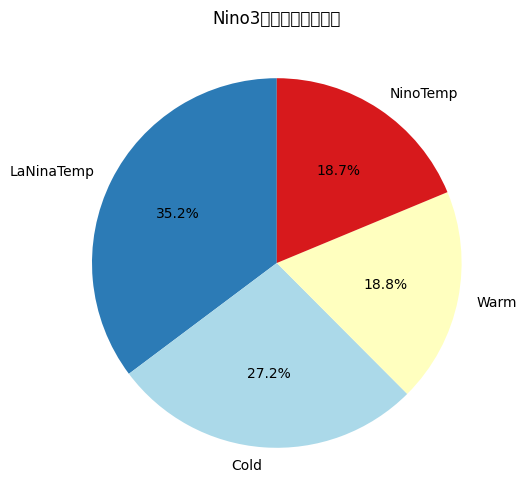

,Date,Nino 3,Label
1766,1997-December-01,3.24,NinoTemp


In [ ]:
# 读取正确文件（注意文件名）
df = pd.read_csv('12.nino3.long.anom.data.csv')
# 融化数据：月份转长列
df_melt = df.melt(id_vars='Year', var_name='Month', value_name='Nino 3')
# 生成日期（格式：年-月-01）
df_melt['Date'] = df_melt.apply(lambda x: f"{x['Year']}-{x['Month'].title()}-01", axis=1)
# 保存结果（无缺失值，无需dropna）
df_melt[['Date', 'Nino 3']].to_csv('nino3_processed.txt', index=False, sep=',')

df = pd.read_csv('nino3_processed.txt')
max_val = df['Nino 3'].max()
min_val = df['Nino 3'].min()
mean_val = df['Nino 3'].mean()
print(f"最大值: {max_val:.2f}（1997年12月）")
print(f"最小值: {min_val:.2f}（1955年11月）")
print(f"平均值: {mean_val:.2f}")

df = pd.read_csv('nino3_processed.txt')
# 动态分箱（根据数据实际范围）
df['Label'] = pd.cut(
    df['Nino 3'],
    bins=[-3, -0.5, 0, 0.5, 4],  # 扩展边界覆盖极值
    labels=['LaNinaTemp', 'Cold', 'Warm', 'NinoTemp'])
df.to_csv('nino3_classified.csv', index=False)
# 绘制饼图
plt.figure(figsize=(8, 6))
plt.pie(df['Label'].value_counts(), labels=['LaNinaTemp', 'Cold', 'Warm', 'NinoTemp'], autopct='%1.1f%%', startangle=90, colors=['#2c7bb6', '#abd9e9', '#ffffbf', '#d7191c'])
plt.title('Nino3海温异常状态分布')
plt.savefig('nino3_distribution.png', dpi=300)
plt.show()
import pandas as pd

df = pd.read_csv('nino3_classified.csv')
lanina_starts, nino_starts = [], []
current_label, start_date, count = None, None, 0
for idx, row in df.iterrows():
    label = row['Label']
    if label == 'LaNinaTemp':
        if current_label == 'LaNinaTemp':
            count += 1
        else:
            current_label = 'LaNinaTemp'
            count = 1
            start_date = row['Date']
        if count >= 6:
            lanina_starts.append(start_date)
            count = 0  # 重置计数，避免重复记录
    elif label == 'NinoTemp':
        if current_label == 'NinoTemp':
            count += 1
        else:
            current_label = 'NinoTemp'
            count = 1
            start_date = row['Date']
        if count >= 6:
            nino_starts.append(start_date)
            count = 0  # 重置计数
    else:
        current_label, start_date, count = None, None, 0  # 非异常状态重置
# 保存结果
with open('LaNinaStartDates.txt', 'w') as f:
    f.write('\n'.join(lanina_starts))
with open('NinoStartDates.txt', 'w') as f:
    f.write('\n'.join(nino_starts))